# ACS Income experiments

In [ ]:
from boundary_trace import GroupScoreDistribution, trace_intersection
from plotting import plot_feasible_regions, styled_boxplot
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

## Helper functions

In [ ]:
# Equal-mass histogram-binning group calibration

def fit_group_bins(T_cal, Y_cal, A_cal, T_test, A_test, k):
  scores = {}
  weights = {}
  J_test = np.full(len(T_test), -1, dtype=int)

  for a in range(2):
    mask_cal = (A_cal == a)
    mask_test = (A_test == a)

    order_cal = np.argsort(T_cal[mask_cal])
    bins_cal = np.array_split(order_cal, k)

    if not all(len(bin_) > 0 for bin_ in bins_cal):
      raise ValueError('empty calibration bin')

    scores[a] = np.array([
        Y_cal[mask_cal][bin_].mean()
        for bin_ in bins_cal])

    edges = np.array([
        T_cal[mask_cal][bin_].max()
        for bin_ in bins_cal[:-1]])

    # Store bin indices rather than calibrated score values, to avoid
    # floating-point matching when applying the rule.
    J = np.digitize(T_test[mask_test], edges, right=True)
    J_test[mask_test] = J

    weights[a] = np.array([
        np.mean(J == b)
        for b in range(k)])

  if np.any(J_test < 0):
    raise ValueError('some test points were not assigned to bins')

  if not all(np.isclose(weights[a].sum(), 1) for a in range(2)):
    raise ValueError('weights do not sum to 1')

  return scores, weights, J_test

In [ ]:
# Apply decision rule on data

def get_R_from_rules(rules, J, A):
  R = np.full(len(J), np.nan)

  for a in range(2):
    for b in range(len(rules[a])):
      R[(A == a) & (J == b)] = rules[a][b]

  if np.isnan(R).any():
    raise ValueError('some test points were not assigned a decision probability')

  return R

In [ ]:
# Compute classifier statistics

def get_stats_from_R(R, Y, A):
  ps, qs = [], []

  for a in range(2):
    mask = (A == a)

    p = np.mean(R[mask] * Y[mask]) / np.mean(R[mask])
    q = np.mean((1 - R[mask]) * Y[mask]) / np.mean(1 - R[mask])

    ps.append(p)
    qs.append(q)

  acc = np.mean(R * Y + (1 - R) * (1 - Y))

  return ps, qs, acc

In [ ]:
# Summarization helpers

def bootstrap_ci(x, n_boot=10000, alpha=0.05, seed=0):
  rng = np.random.default_rng(seed)
  x = np.asarray(x)

  means = [
      rng.choice(x, size=len(x), replace=True).mean()
      for _ in range(n_boot)]

  return np.quantile(means, [alpha / 2, 1 - alpha / 2])

def summarize(x):
  ci = bootstrap_ci(x)
  return f'{np.mean(x):.4f} [{ci[0]:.4f}, {ci[1]:.4f}]'

## Data and predictor

In [ ]:
acs = fetch_openml(data_id=43141, as_frame=True)
df = acs.frame

df = df[df['ST'].astype(int) == 6]  # California

Y = (df['PINCP'].astype(float) > 50000).astype(int).to_numpy()
A = (df['SEX'].astype(int) == 2).astype(int).to_numpy()  # Female=1, Male=0

columns_X = [
    'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP',
    'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P']

X = df[columns_X]
strata = 2 * A + Y

In [ ]:
# Logistic regression model

def make_predictor(X):
  num_cols = [c for c in ['AGEP', 'WKHP'] if c in X.columns]
  cat_cols = [c for c in X.columns if c not in num_cols]

  preprocess = ColumnTransformer(transformers=[
      ('num', StandardScaler(), num_cols),
      ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist',
                            min_frequency=20,
                            sparse_output=True), cat_cols)],
      sparse_threshold=1.0)

  return Pipeline([
      ('preprocess', preprocess),
      ('lr', SGDClassifier(loss='log_loss',
                           penalty='l2',
                           alpha=1e-5,
                           max_iter=1000,
                           tol=1e-3,
                           average=True,
                           random_state=0))])

## Main experiment

In [ ]:
seed = 42
np.random.seed(seed)

# For a quick test, use n_reps=5 and n_cal_reps=2.
# For the paper results, use n_reps=100 and n_cal_reps=20.
n_reps = 100
n_cal_reps = 20
cal_fractions = [0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0]
k = 100

n_rhos = len(cal_fractions)

ps = np.full((n_reps, n_rhos, n_cal_reps, 2), np.nan)
qs = np.full((n_reps, n_rhos, n_cal_reps, 2), np.nan)
accs = np.full((n_reps, n_rhos, n_cal_reps), np.nan)

ps_unconstrained = np.full((n_reps, 2), np.nan)
qs_unconstrained = np.full((n_reps, 2), np.nan)
accs_unconstrained = np.full(n_reps, np.nan)

example_result = None

for i in tqdm(range(n_reps)):
  X_train, X_test, Y_train, Y_test, A_train, A_test = train_test_split(
      X, Y, A,
      test_size=0.2,
      random_state=seed + 1000000 + i,
      stratify=strata)

  strata_train = 2 * A_train + Y_train

  skf = StratifiedKFold(
      n_splits=5,
      shuffle=True,
      random_state=seed + 2000000 + i)

  splits = list(skf.split(X_train, strata_train))

  # Out-of-fold scores are used as calibration data, avoiding reuse of
  # each point in both training and calibration.
  pred = make_predictor(X_train)
  T_cal_full = cross_val_predict(
      pred,
      X_train,
      Y_train,
      cv=splits,
      method='predict_proba',
      n_jobs=1)[:, 1]

  pred = make_predictor(X_train)
  pred.fit(X_train, Y_train)
  T_test = pred.predict_proba(X_test)[:, 1]

  prob_a1 = np.mean(A_test)

  for r, rho in enumerate(cal_fractions):
    n_inner_reps = n_cal_reps if rho < 1 else 1

    for j in range(n_inner_reps):

      # rho=1 gives the full-calibration experiment; smaller rho values are
      # used for the calibration-subsampling experiment.
      if rho < 1:
        T_cal, _, Y_cal, _, A_cal, _ = train_test_split(
            T_cal_full,
            Y_train,
            A_train,
            train_size=rho,
            stratify=strata_train,
            random_state=seed + 3000000 + 100000 * i + 1000 * r + j)
      else:
        T_cal = T_cal_full
        Y_cal = Y_train
        A_cal = A_train

      scores, weights, J_test = fit_group_bins(
          T_cal, Y_cal, A_cal,
          T_test, A_test,
          k=k)

      dist0 = GroupScoreDistribution(scores[0], weights[0], name='Male')
      dist1 = GroupScoreDistribution(scores[1], weights[1], name='Female')

      result = trace_intersection(dist0, dist1, prob_a1)

      rules = [
          dist0.selection_rule(result.max_acc.p, result.max_acc.q),
          dist1.selection_rule(result.max_acc.p, result.max_acc.q)]

      R_test = get_R_from_rules(rules, J_test, A_test)
      ps_, qs_, acc_ = get_stats_from_R(R_test, Y_test, A_test)

      ps[i, r, j] = ps_
      qs[i, r, j] = qs_
      accs[i, r, j] = acc_

      if rho == 1 and j == 0 and example_result is None:
        example_result = result

  R_unconstrained = (T_test >= 0.5)
  ps_, qs_, acc_ = get_stats_from_R(R_unconstrained, Y_test, A_test)

  ps_unconstrained[i] = ps_
  qs_unconstrained[i] = qs_
  accs_unconstrained[i] = acc_

100%|██████████| 100/100 [40:58<00:00, 24.58s/it]


## Basic results (full calibration set)

In [ ]:
ps_basic = ps[:, -1, 0]
qs_basic = qs[:, -1, 0]
accs_basic = accs[:, -1, 0]

p_gap_basic = abs(ps_basic[:, 0] - ps_basic[:, 1])
q_gap_basic = abs(qs_basic[:, 0] - qs_basic[:, 1])

p_gap_unconstrained = abs(ps_unconstrained[:, 0] - ps_unconstrained[:, 1])
q_gap_unconstrained = abs(qs_unconstrained[:, 0] - qs_unconstrained[:, 1])

print('Post-processed classifier:\n'
      f'  PPV_0:    {summarize(ps_basic[:, 0])}\n'
      f'  PPV_1:    {summarize(ps_basic[:, 1])}\n'
      f'  PPV gap:  {summarize(p_gap_basic)}\n'
      f'  FOR_0:    {summarize(qs_basic[:, 0])}\n'
      f'  FOR_1:    {summarize(qs_basic[:, 1])}\n'
      f'  FOR gap:  {summarize(q_gap_basic)}\n'
      f'  accuracy: {summarize(accs_basic)}\n'
      'Unconstrained classifier:\n'
      f'  PPV_0:    {summarize(ps_unconstrained[:, 0])}\n'
      f'  PPV_1:    {summarize(ps_unconstrained[:, 1])}\n'
      f'  PPV gap:  {summarize(p_gap_unconstrained)}\n'
      f'  FOR_0:    {summarize(qs_unconstrained[:, 0])}\n'
      f'  FOR_1:    {summarize(qs_unconstrained[:, 1])}\n'
      f'  FOR gap:  {summarize(q_gap_unconstrained)}\n'
      f'  accuracy: {summarize(accs_unconstrained)}')

Post-processed classifier:
  PPV_0:    0.7758 [0.7747, 0.7769]
  PPV_1:    0.7768 [0.7755, 0.7782]
  PPV gap:  0.0048 [0.0042, 0.0055]
  FOR_0:    0.1545 [0.1533, 0.1557]
  FOR_1:    0.1549 [0.1539, 0.1558]
  FOR gap:  0.0037 [0.0032, 0.0043]
  accuracy: 0.8167 [0.8164, 0.8171]
Unconstrained classifier:
  PPV_0:    0.7961 [0.7955, 0.7967]
  PPV_1:    0.7600 [0.7592, 0.7608]
  PPV gap:  0.0361 [0.0351, 0.0371]
  FOR_0:    0.1728 [0.1722, 0.1734]
  FOR_1:    0.1400 [0.1395, 0.1404]
  FOR gap:  0.0329 [0.0321, 0.0336]
  accuracy: 0.8190 [0.8187, 0.8194]


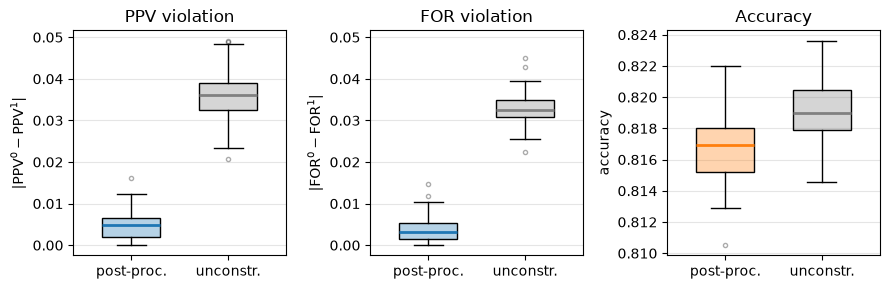

In [ ]:
# Figure

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True)

styled_boxplot(axs[0], [p_gap_basic], [0],
               'violation', width=0.6)
styled_boxplot(axs[0], [p_gap_unconstrained], [1],
               'unconstrained', width=0.6)
axs[0].set_ylabel(r'$|\mathrm{PPV}^0-\mathrm{PPV}^1|$')
axs[0].set_title('PPV violation')

styled_boxplot(axs[1], [q_gap_basic], [0],
               'violation', width=0.6)
styled_boxplot(axs[1], [q_gap_unconstrained], [1],
               'unconstrained', width=0.6)
axs[1].set_ylabel(r'$|\mathrm{FOR}^0-\mathrm{FOR}^1|$')
axs[1].set_title('FOR violation')
axs[1].sharey(axs[0])

styled_boxplot(axs[2], [accs_basic], [0],
               'accuracy', width=0.6)
styled_boxplot(axs[2], [accs_unconstrained], [1],
               'unconstrained', width=0.6)
axs[2].set_ylabel('accuracy')
axs[2].set_title('Accuracy')

for ax in axs:
  ax.set_xlim(-0.6, 1.6)
  ax.set_xticks([0, 1], labels=['post-proc.', 'unconstr.'])
  ax.grid(axis='y', alpha=0.33)

fig.tight_layout()

## Calibration-subsampling results

In [ ]:
p_gap = np.nanmean(abs(ps[..., 0] - ps[..., 1]), axis=2)
q_gap = np.nanmean(abs(qs[..., 0] - qs[..., 1]), axis=2)
accs_mean = np.nanmean(accs, axis=2)

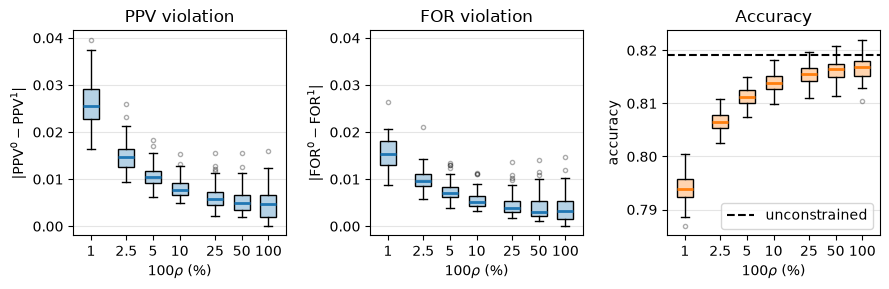

In [ ]:
# Figure

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True)

positions = np.log10(cal_fractions)

styled_boxplot(axs[0], p_gap, positions, 'violation')
axs[0].set_ylabel(r'$|\mathrm{PPV}^0-\mathrm{PPV}^1|$')
axs[0].set_title('PPV violation')

styled_boxplot(axs[1], q_gap, positions, 'violation')
axs[1].set_ylabel(r'$|\mathrm{FOR}^0-\mathrm{FOR}^1|$')
axs[1].set_title('FOR violation')
axs[1].sharey(axs[0])

styled_boxplot(axs[2], accs_mean, positions, 'accuracy')
axs[2].axhline(np.mean(accs_unconstrained),
    ls='--', c='black', label='unconstrained')
axs[2].set_ylabel('accuracy')
axs[2].set_title('Accuracy')
axs[2].legend()

for ax in axs:
  ax.set_xticks(
      positions,
      labels=[f'{100 * rho:g}' for rho in cal_fractions])
  ax.set_xlabel(r'$100\rho$ (%)')
  ax.grid(axis='y', alpha=0.33)

fig.tight_layout()

## Example feasible regions

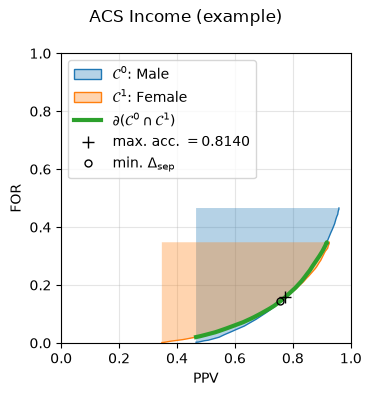

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

plot_feasible_regions(ax, example_result)

fig.suptitle('ACS Income (example)')
fig.tight_layout()